# Phase 2 -- N-gram language models

Lab experiment covering `nticipate/ngram.py`: bigram/trigram counting,
four smoothing methods (MLE, Laplace, stupid backoff, interpolated
Kneser-Ney), perplexity evaluation, pruning for app packaging, and
qualitative sentence generation.

Runs against the same sample corpus as Phase 1 by default -- swap
`CORPUS_SOURCE = "nltk"` once `setup_env.py` has downloaded the full
corpora, for the real submission numbers.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import random

from nticipate.config import load_config, resolve_path
from nticipate.preprocess import preprocess_corpus, train_dev_test_split
from nticipate.ngram import NgramModel, build_ngram_hierarchy

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)

## 1. Load, preprocess, and split

In [2]:
if CORPUS_SOURCE == "sample":
    with open(resolve_path("data/raw/sample_english.txt"), encoding="utf-8") as f:
        raw_text = f.read()
    raw_documents = [p for p in raw_text.split("\n\n") if p.strip()]
else:
    import nltk
    raw_documents = []
    for corpus_name in CFG["preprocessing"]["corpora_english"]:
        corpus = getattr(nltk.corpus, corpus_name)
        for fileid in corpus.fileids():
            raw_documents.append(corpus.raw(fileid))

unk_applied_sentences, vocab, truecase_map = preprocess_corpus(raw_documents)
train_sents, dev_sents, test_sents = train_dev_test_split(unk_applied_sentences)

print(f"Vocab size:      {len(vocab)}")
print(f"Train sentences: {len(train_sents)}")
print(f"Dev sentences:   {len(dev_sents)}")
print(f"Test sentences:  {len(test_sents)}")

Vocab size:      71
Train sentences: 48
Dev sentences:   6
Test sentences:  6


## 2. MLE: the zero-probability problem

Before touching smoothing, show *why* smoothing is necessary: MLE
assigns exact zero probability to any bigram/trigram that didn't occur
in training, which breaks perplexity outright on held-out data.

In [3]:
mle_models = build_ngram_hierarchy(train_sents, orders=[1, 2, 3], smoothing="mle", vocab=vocab)

sample_dev_sentence = dev_sents[0] if dev_sents else train_sents[0]
print("Dev sentence:", sample_dev_sentence)

for n in [1, 2, 3]:
    model = mle_models[n]
    zero_count = 0
    total = 0
    from nticipate.preprocess import pad_sentence
    padded = pad_sentence(sample_dev_sentence, n)
    for i in range(n - 1, len(padded)):
        context = tuple(padded[i - n + 1 : i])
        word = padded[i]
        total += 1
        if model.prob(word, context) == 0.0:
            zero_count += 1
    print(f"n={n}: {zero_count}/{total} n-grams in this dev sentence have exact zero MLE probability")

Dev sentence: ['the', '<UNK>', '<UNK>', 'a', 'bug', 'in', 'the', '<UNK>', '.']
n=1: 0/10 n-grams in this dev sentence have exact zero MLE probability
n=2: 2/10 n-grams in this dev sentence have exact zero MLE probability
n=3: 4/10 n-grams in this dev sentence have exact zero MLE probability


## 3. Perplexity sweep: order x smoothing method

The core Phase 2 deliverable. Perplexity on dev data, for every
combination of n-gram order and smoothing method.

In [4]:
orders = CFG["ngram"]["orders"]
smoothing_methods = ["mle", "laplace", "stupid_backoff", "kneser_ney"]

results = {}  # (n, smoothing) -> perplexity
for smoothing in smoothing_methods:
    models = build_ngram_hierarchy(train_sents, orders=orders, smoothing=smoothing, vocab=vocab)
    for n in orders:
        pp = models[n].perplexity(dev_sents if dev_sents else train_sents)
        results[(n, smoothing)] = pp
        print(f"n={n}  smoothing={smoothing:15s}  perplexity={pp:12.2f}")

n=1  smoothing=mle              perplexity=       12.45
n=2  smoothing=mle              perplexity=      134.95
n=3  smoothing=mle              perplexity=    31000.27
n=1  smoothing=laplace          perplexity=       12.59
n=2  smoothing=laplace          perplexity=       11.41
n=3  smoothing=laplace          perplexity=       17.92
n=1  smoothing=stupid_backoff   perplexity=       12.45
n=2  smoothing=stupid_backoff   perplexity=        6.83
n=3  smoothing=stupid_backoff   perplexity=        8.40
n=1  smoothing=kneser_ney       perplexity=       18.74
n=2  smoothing=kneser_ney       perplexity=        7.29
n=3  smoothing=kneser_ney       perplexity=        7.18


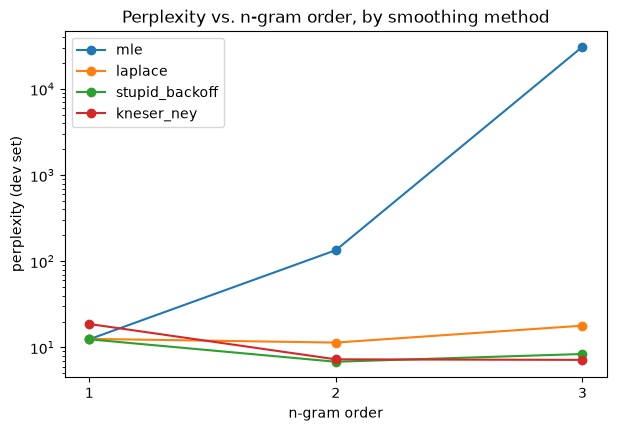

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for smoothing in smoothing_methods:
    ys = [results[(n, smoothing)] for n in orders]
    ax.plot(orders, ys, marker="o", label=smoothing)
ax.set_xlabel("n-gram order")
ax.set_ylabel("perplexity (dev set)")
ax.set_yscale("log")
ax.set_xticks(orders)
ax.set_title("Perplexity vs. n-gram order, by smoothing method")
ax.legend()
plt.show()

**What to look for**: MLE perplexity should be enormous (or effectively
infinite before flooring) at n=2 and n=3 -- that's the sparsity problem
from section 2 showing up numerically. Kneser-Ney should sit lowest at
higher orders; stupid backoff should track reasonably close behind it
at a fraction of the computational cost, which is why it -- not KN --
ships in the live predictor (Phase 3).

## 4. Sparsity vs. order trade-off

Trigrams capture more context than bigrams, but each trigram context is
proportionally rarer in a fixed-size corpus. Compare vocabulary of
*contexts* seen at each order -- this is the tension worth a paragraph
in the report.

In [6]:
laplace_models = build_ngram_hierarchy(train_sents, orders=orders, smoothing="laplace", vocab=vocab)
for n in orders:
    model = laplace_models[n]
    num_contexts = len(model.counts)
    num_singleton_contexts = sum(1 for wc in model.counts.values() if sum(wc.values()) == 1)
    print(f"n={n}: {num_contexts} distinct contexts, {num_singleton_contexts} seen only once "
          f"({num_singleton_contexts/max(num_contexts,1):.1%} of contexts)")

n=1: 1 distinct contexts, 0 seen only once (0.0% of contexts)
n=2: 67 distinct contexts, 10 seen only once (14.9% of contexts)
n=3: 198 distinct contexts, 134 seen only once (67.7% of contexts)


## 5. Qualitative generation: unigram vs. bigram vs. trigram

The fun demo. Unigram output should read as word salad (no local
coherence at all); trigram output should be closer to grammatical,
even on this small a corpus.

In [7]:
gen_models = build_ngram_hierarchy(train_sents, orders=[1, 2, 3], smoothing="laplace", vocab=vocab)

# multiple samples per order -- on a small corpus a single draw can hit
# </s> almost immediately (itself a real symptom of data sparsity, see
# section 4), so look at 3 draws per order rather than judging on one
for n in [1, 2, 3]:
    print(f"--- n={n} ---")
    for seed in range(3):
        tokens = gen_models[n].generate(max_len=15, rng=random.Random(seed))
        print("  ", " ".join(tokens) if tokens else "(empty -- hit </s> immediately)")


--- n=1 ---
   the often <UNK> <UNK> a <UNK> ran <UNK> <UNK> asked the <UNK> <UNK> of city
   (empty -- hit </s> immediately)
   together to . . the new for <UNK> by by asked
--- n=2 ---
   the of farmer by in hard the <UNK> a large understand it castle she natural
   <UNK> the often bug history he on the <UNK> . new flour slowly , hard
   two wheat
--- n=3 ---
   the race flour city in flour students did history n't understand in coffee slowly of
   <UNK> sugar student cat hours he on sugar after . they hard student , he
   two wheat <UNK> about they she park did new new n't at hard farmer recipe


A very short draw (or an empty one) at n=2/n=3 isn't a bug -- on this small a corpus, many bigram/trigram contexts assign real probability mass to `</s>` simply because they were seen only a handful of times. It's the same sparsity problem from section 4 showing up in generation instead of perplexity. This effect shrinks substantially on the full NLTK corpora.


## 6. Pruning: size vs. quality trade-off

The app can't ship an unpruned model -- Phase 8's packaging step
depends on this. Compare model size and perplexity before/after
pruning to quantify the trade-off you're making.

In [8]:
prune_model = build_ngram_hierarchy(train_sents, orders=[3], smoothing="stupid_backoff", vocab=vocab)[3]

size_before = prune_model.model_size_estimate()
pp_before = prune_model.perplexity(dev_sents if dev_sents else train_sents)

prune_model.prune()  # uses CFG['ngram']['prune_min_count'] / prune_top_k_per_context

size_after = prune_model.model_size_estimate()
pp_after = prune_model.perplexity(dev_sents if dev_sents else train_sents)

print(f"{'':20s}{'before':>15s}{'after':>15s}")
print(f"{'contexts':20s}{size_before['num_contexts']:15d}{size_after['num_contexts']:15d}")
print(f"{'entries':20s}{size_before['num_entries']:15d}{size_after['num_entries']:15d}")
print(f"{'size (bytes)':20s}{size_before['size_bytes']:15d}{size_after['size_bytes']:15d}")
print(f"{'perplexity':20s}{pp_before:15.2f}{pp_after:15.2f}")

                             before          after
contexts                        198             32
entries                         322             50
size (bytes)                   5865            937
perplexity                    18.08          22.39


## Summary table (paste into report)

| n | smoothing | perplexity (dev) |
|---|---|---|
| fill in from section 3 output | | |

| | before pruning | after pruning |
|---|---|---|
| contexts | | |
| entries | | |
| size (bytes) | | |
| perplexity | | |

Re-run with `CORPUS_SOURCE = "nltk"` for the full-corpus numbers used
in the actual submission -- expect perplexity to drop noticeably and
the MLE zero-probability problem in section 2 to become even more
pronounced (more unique trigrams means proportionally more of them are
singletons).